In [32]:

# --- Jupyter Notebook Cell ---

# 1. Imports
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# import all functions from all the modules in the code directory
from data_loader import *
from data_eda import *
from data_labels import *
from data_prep import *
from data_quality import *
from data_transform import *
from data_features import *
import torch
from nn_architecture import *
import itertools
import torch.optim as optim
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score,accuracy_score,classification_report, confusion_matrix,auc,roc_auc_score,precision_recall_curve


import random



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
DATA_DIR = "C:\\Users\\chenj\\Downloads\\thermal-prediction\\thermal-prediction\\data\\raw"

raw_df = load_and_merge_sessions(DATA_DIR)
df_no_gaps = trim_and_handle_gaps(raw_df) #Fill timestamp gap
df_imputed = handle_missing_values(df_no_gaps, missing_threshold=0.1) #Fill NaN
df_final = construct_labels(df_imputed, temp_threshold_c=75.0) #Why predict future label of the current data?
verify_target_distribution(df_final) # What represents thermal_pressure_code



2026-07-10 18:03:55,836 [INFO] Loaded mac_m1_20260701_001 with 2071 rows.
2026-07-10 18:03:55,844 [INFO] Loaded mac_m1_20260702_001 with 1886 rows.
2026-07-10 18:03:55,852 [INFO] Loaded mac_m1_20260703_001 with 1338 rows.
2026-07-10 18:03:55,861 [INFO] Loaded mac_m1_20260704_001 with 2477 rows.
2026-07-10 18:03:55,869 [INFO] Loaded mac_m1_20260705_001 with 1644 rows.
2026-07-10 18:03:55,879 [INFO] Loaded mac_m1_20260706_001 with 2198 rows.
2026-07-10 18:03:55,882 [INFO] Loaded mac_m5_20260625_001 with 211 rows.
2026-07-10 18:03:55,891 [INFO] Loaded mac_m5_20260626_001 with 2261 rows.
2026-07-10 18:03:55,896 [INFO] Loaded mac_m5_20260626_002 with 864 rows.
2026-07-10 18:03:55,900 [INFO] Loaded mac_m5_20260626_003 with 572 rows.
2026-07-10 18:03:55,906 [INFO] Loaded mac_m5_20260627_001 with 1346 rows.
2026-07-10 18:03:55,928 [INFO] Loaded mac_m5_20260701_001 with 6092 rows.
2026-07-10 18:03:55,934 [INFO] Loaded mac_m5_20260703_001 with 990 rows.
2026-07-10 18:03:55,941 [INFO] Successfull


--- Target Variable Distributions ---

Target: Y (binary label)
  Class 0: 21579 rows (91.12%)
  Class 1: 2104 rows (8.88%)

Target: thermal_pressure_code
  Code 0.0: 20003 rows (84.46%)
  Code 2.0: 2118 rows (8.94%)
  Code 3.0: 1033 rows (4.36%)
  Code 1.0: 529 rows (2.23%)


In [3]:
df_final.columns # what are  'loadavg_1m', 'loadavg_5m', 'loadavg_15m'

Index(['timestamp_utc', 'os_family', 'thermal_pressure_level',
       'thermal_pressure_code', 'cpu_die_temp_c', 'cpu_total_active_pct',
       'cpu_ecluster_active_pct', 'cpu_pcluster_active_pct',
       'cpu_ecluster_freq_mhz', 'cpu_pcluster_freq_mhz', 'gpu_active_pct',
       'cpu_power_mw', 'gpu_power_mw', 'combined_power_mw', 'loadavg_1m',
       'loadavg_5m', 'loadavg_15m', 'ram_used_gb', 'mem_pressure_pct',
       'mem_compressed_gb', 'session_id', 'cpu_die_temp_c_is_missing', 'Y'],
      dtype='str')

In [4]:
print_numeric_descriptive_stats(df_final)


--- Descriptive Statistics for Numeric Non-Binary Columns ---


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct
thermal_pressure_code,23683.0,0.332053,0.813874,0.000000,0.000000,0.000000,0.000000,3.000000,0,0.0
cpu_die_temp_c,23683.0,53.218750,12.413392,10.640909,41.345144,52.406250,64.338676,93.700264,0,0.0
cpu_total_active_pct,23683.0,53.254390,19.967266,15.401900,39.375025,49.183250,66.704325,100.000000,0,0.0
cpu_ecluster_active_pct,23683.0,62.057232,21.391296,14.811300,49.031600,58.423400,72.786500,100.000000,0,0.0
cpu_pcluster_active_pct,23683.0,44.451549,26.735240,14.932500,24.062500,34.900700,51.184800,100.000000,0,0.0
cpu_ecluster_freq_mhz,23683.0,1575.944012,348.919109,989.901000,1309.240000,1470.590000,1793.945000,3047.250000,0,0.0
cpu_pcluster_freq_mhz,23683.0,2761.724454,1086.845149,665.651000,1695.720000,2934.650000,3860.320000,4478.910000,0,0.0
gpu_active_pct,23683.0,7.210917,9.223464,0.000000,0.935300,4.212000,9.161700,82.730200,0,0.0
cpu_power_mw,23683.0,3057.284734,4975.691851,418.091000,1005.310000,1466.050000,2541.585000,27578.500000,0,0.0
gpu_power_mw,23683.0,45.773932,97.596819,0.000000,2.192290,13.575200,44.259450,3743.450000,0,0.0


2026-07-10 18:03:56,181 [INFO] Generating KDE plots for 17 variables across a 6x3 grid.


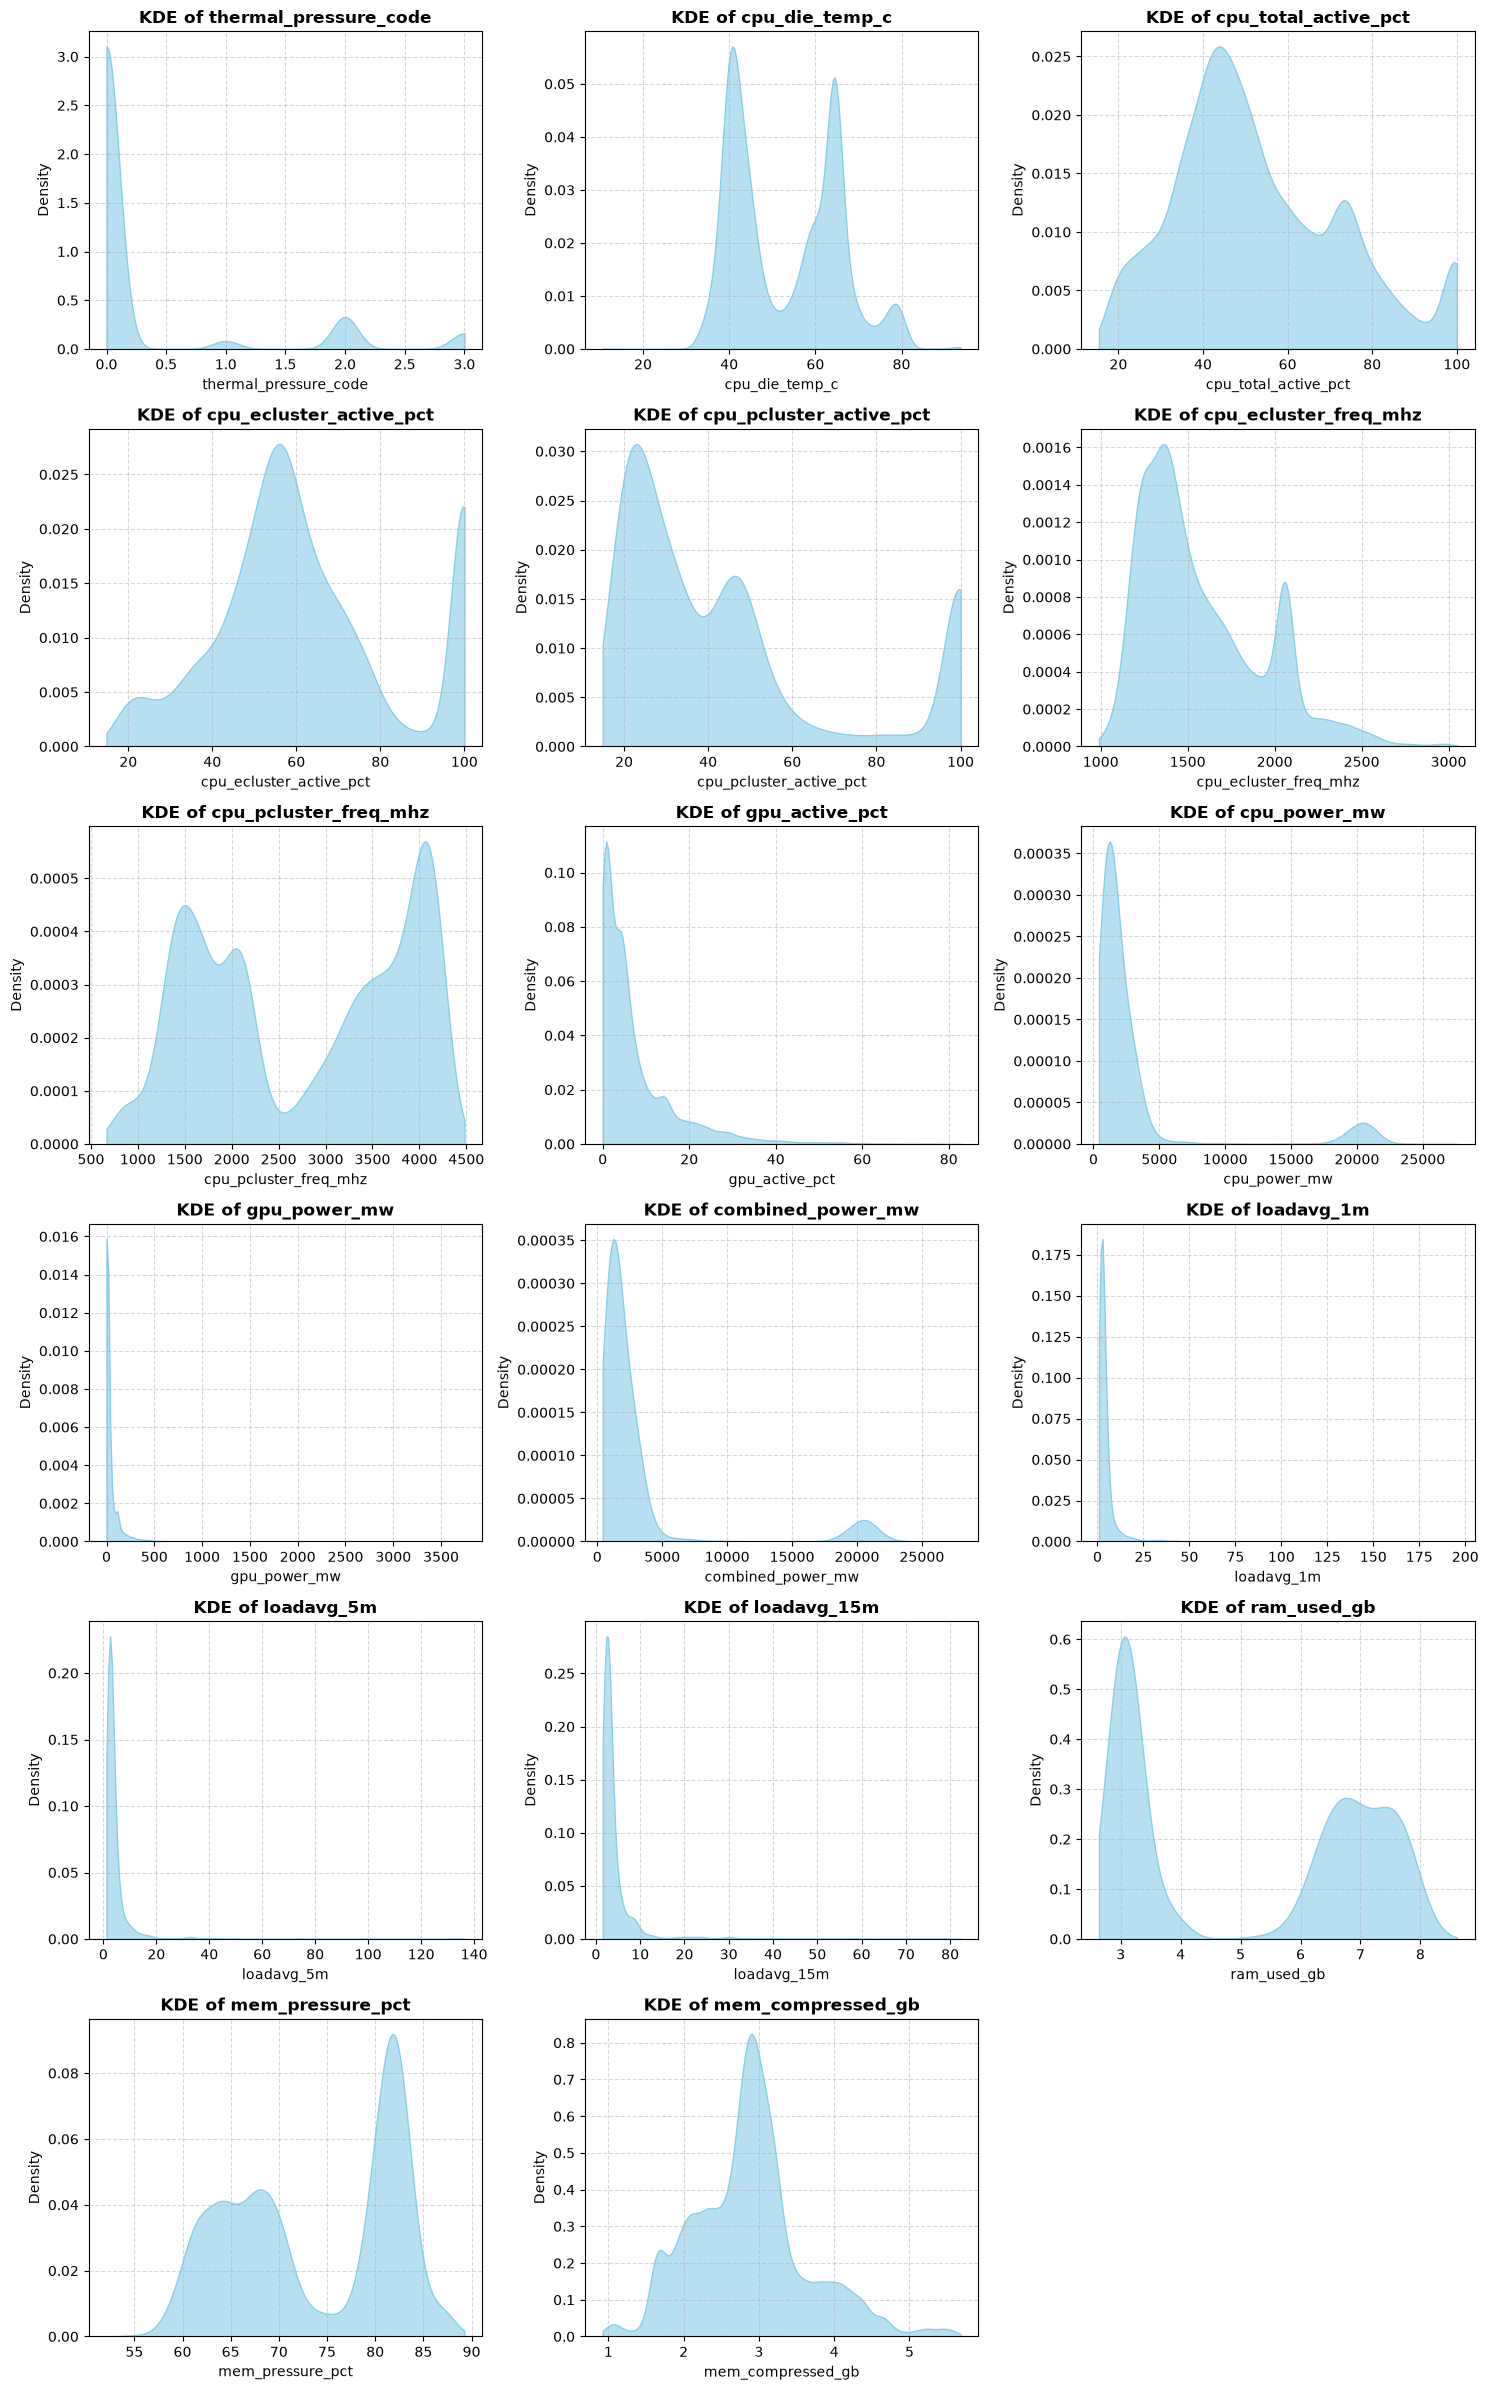

In [5]:
plot_numeric_kdes(df_final)

2026-07-10 18:03:57,836 [WARNING] The following requested columns were missing from the DataFrame and will be skipped: ['cpu_power_mw_is_outlier']
2026-07-10 18:03:57,836 [INFO] Generating pairplot for 8 features...


Notice: No specific columns provided. The pairplot defaults to:
  - mem_compressed_gb
  - cpu_pcluster_freq_mhz
  - cpu_power_mw
  - loadavg_1m
  - cpu_pcluster_active_pct
  - cpu_total_active_pct
  - combined_power_mw
  - cpu_power_mw_is_outlier
  - cpu_ecluster_freq_mhz



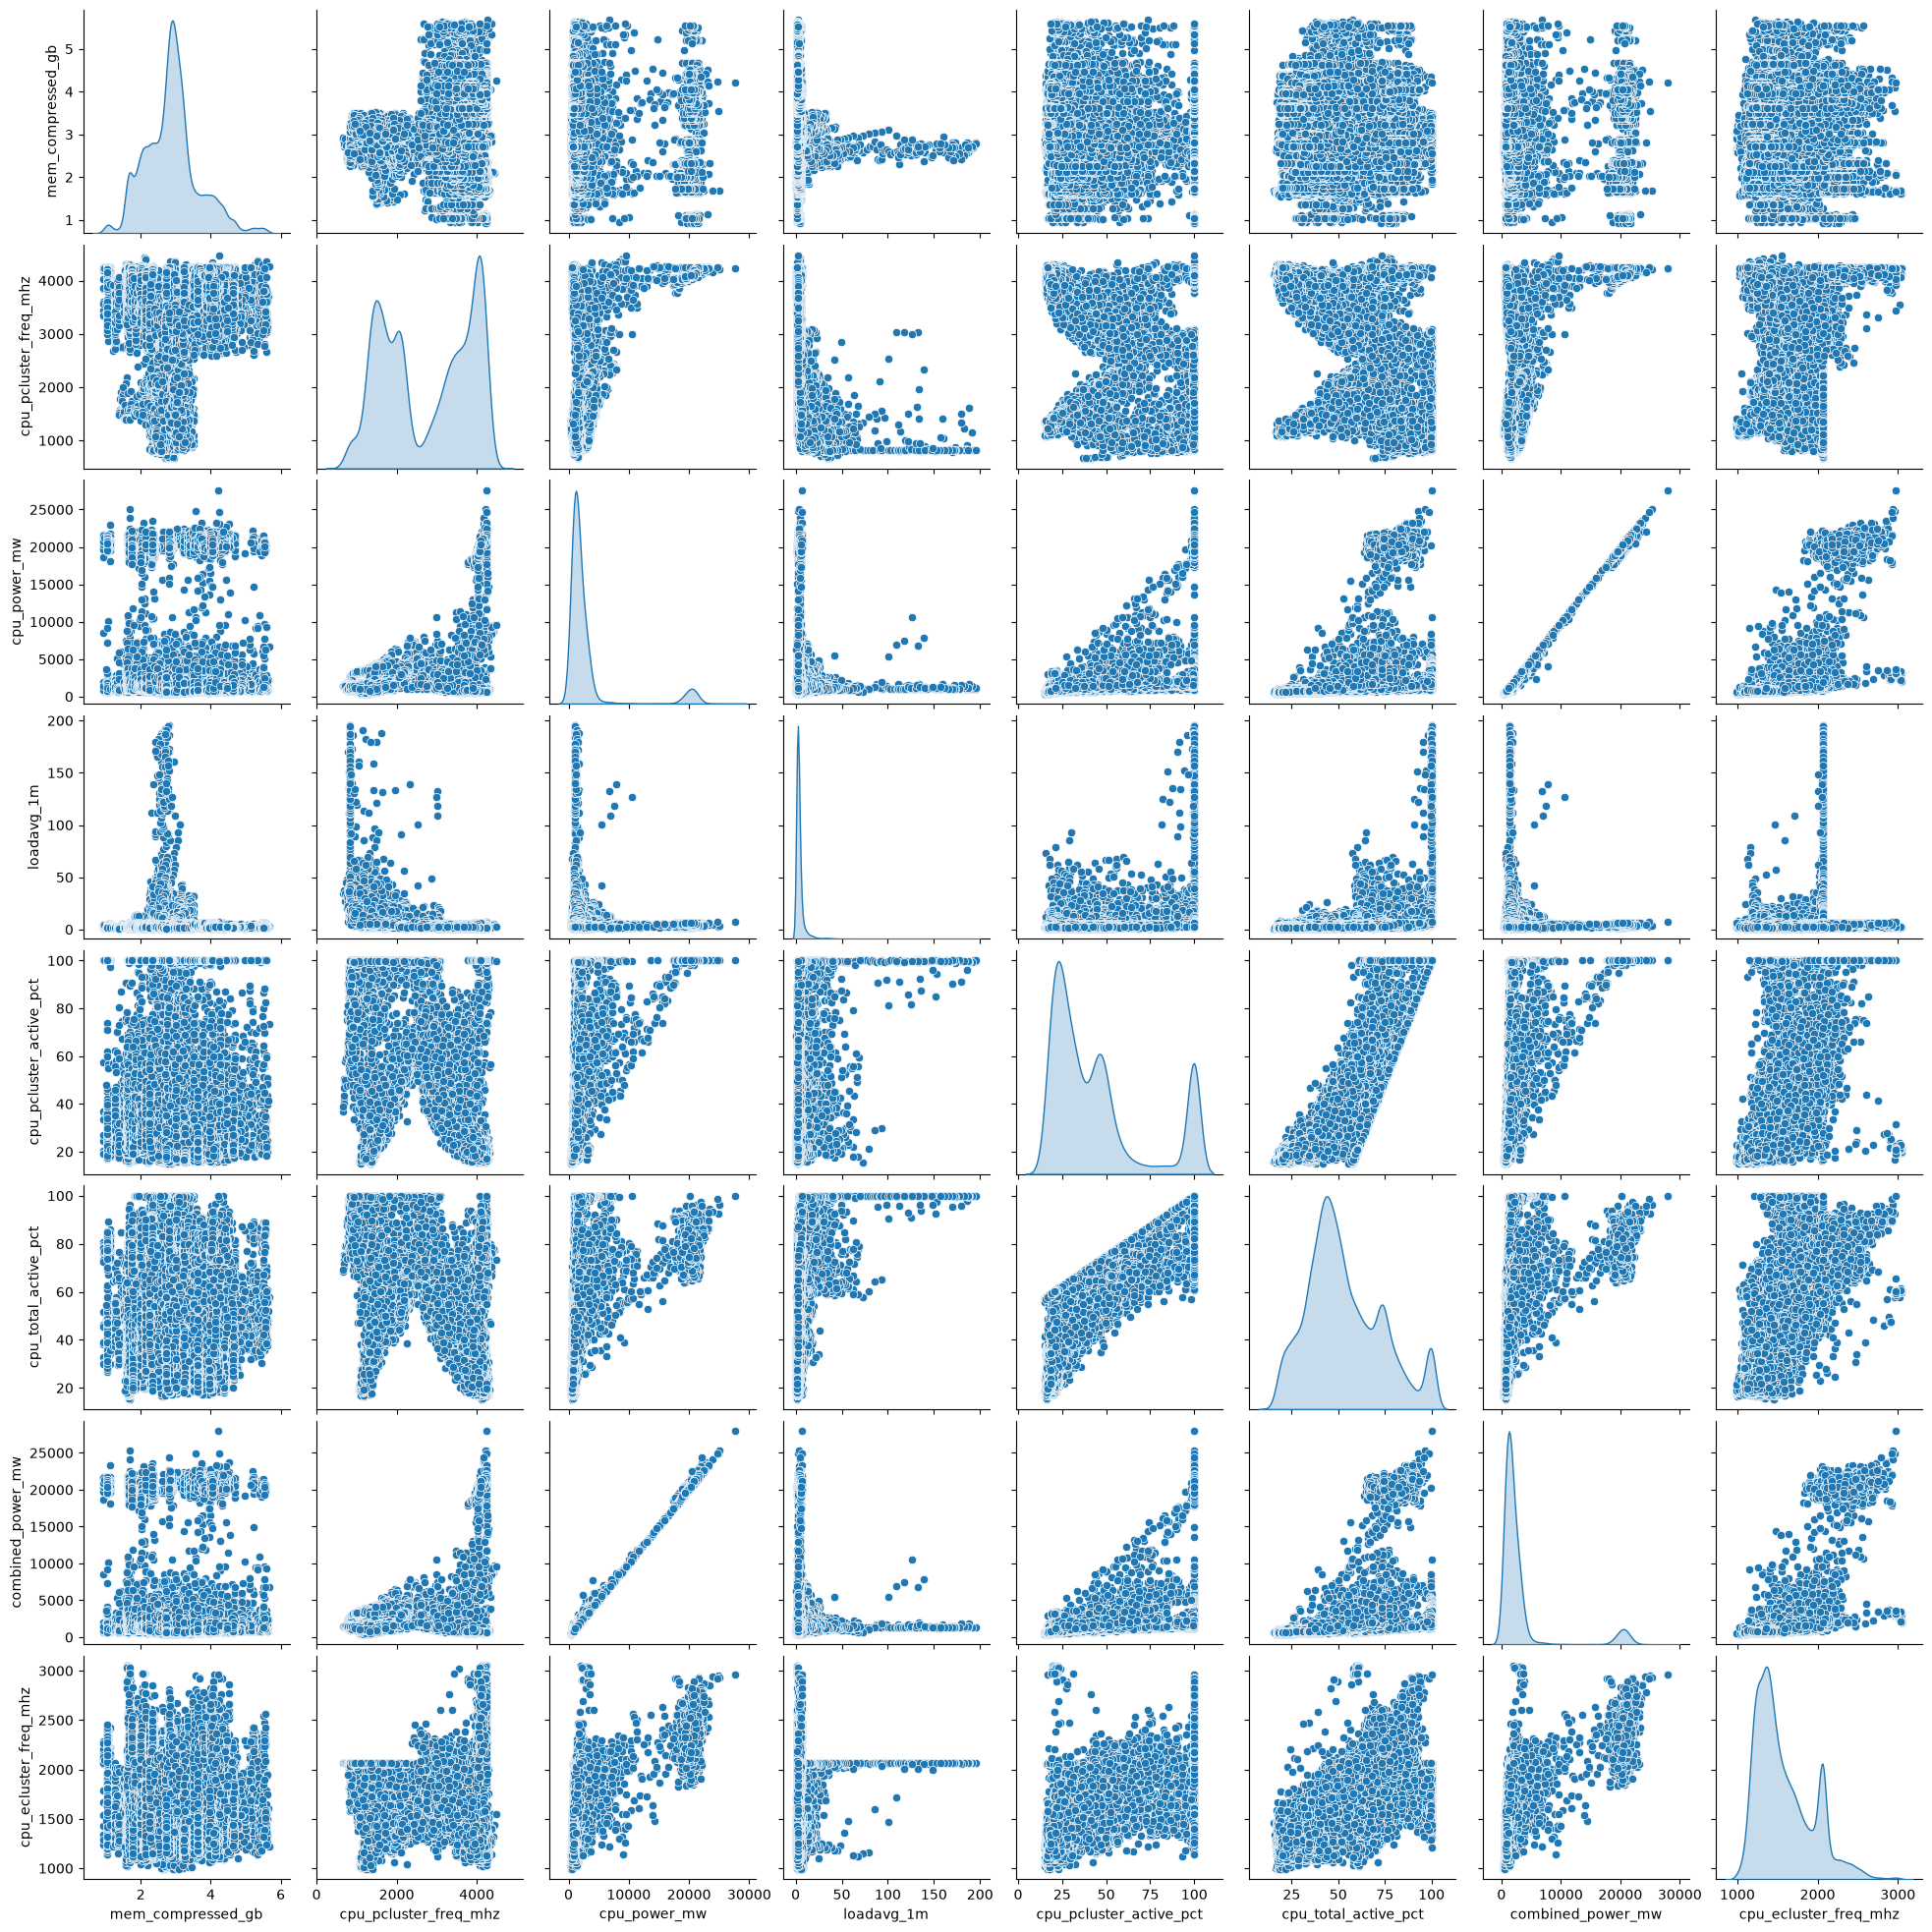

In [6]:
plot_variable_pairplot(df_final)

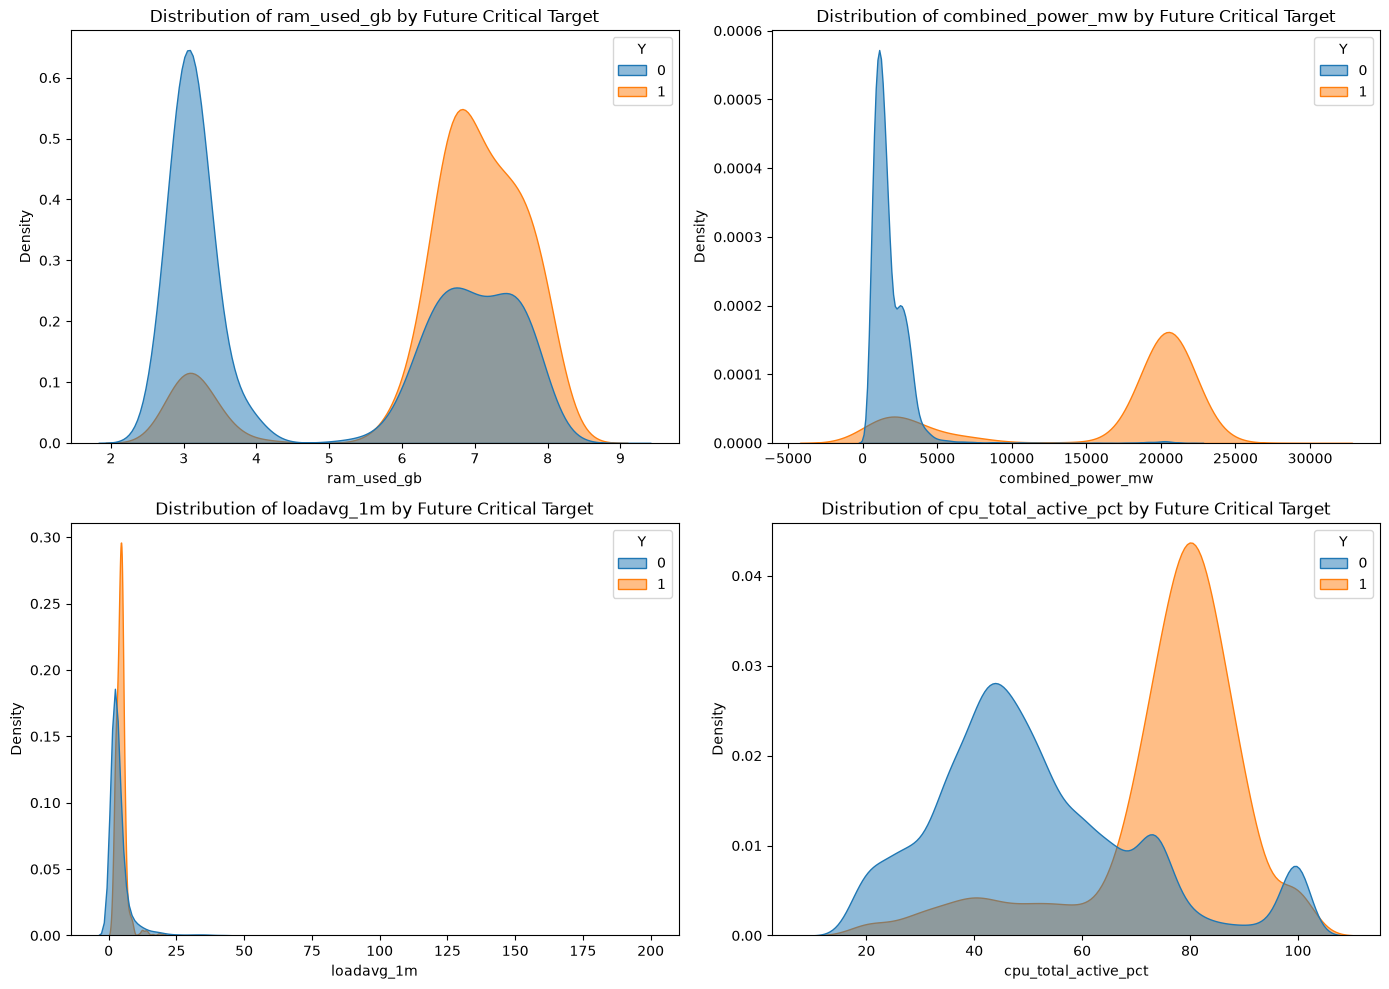

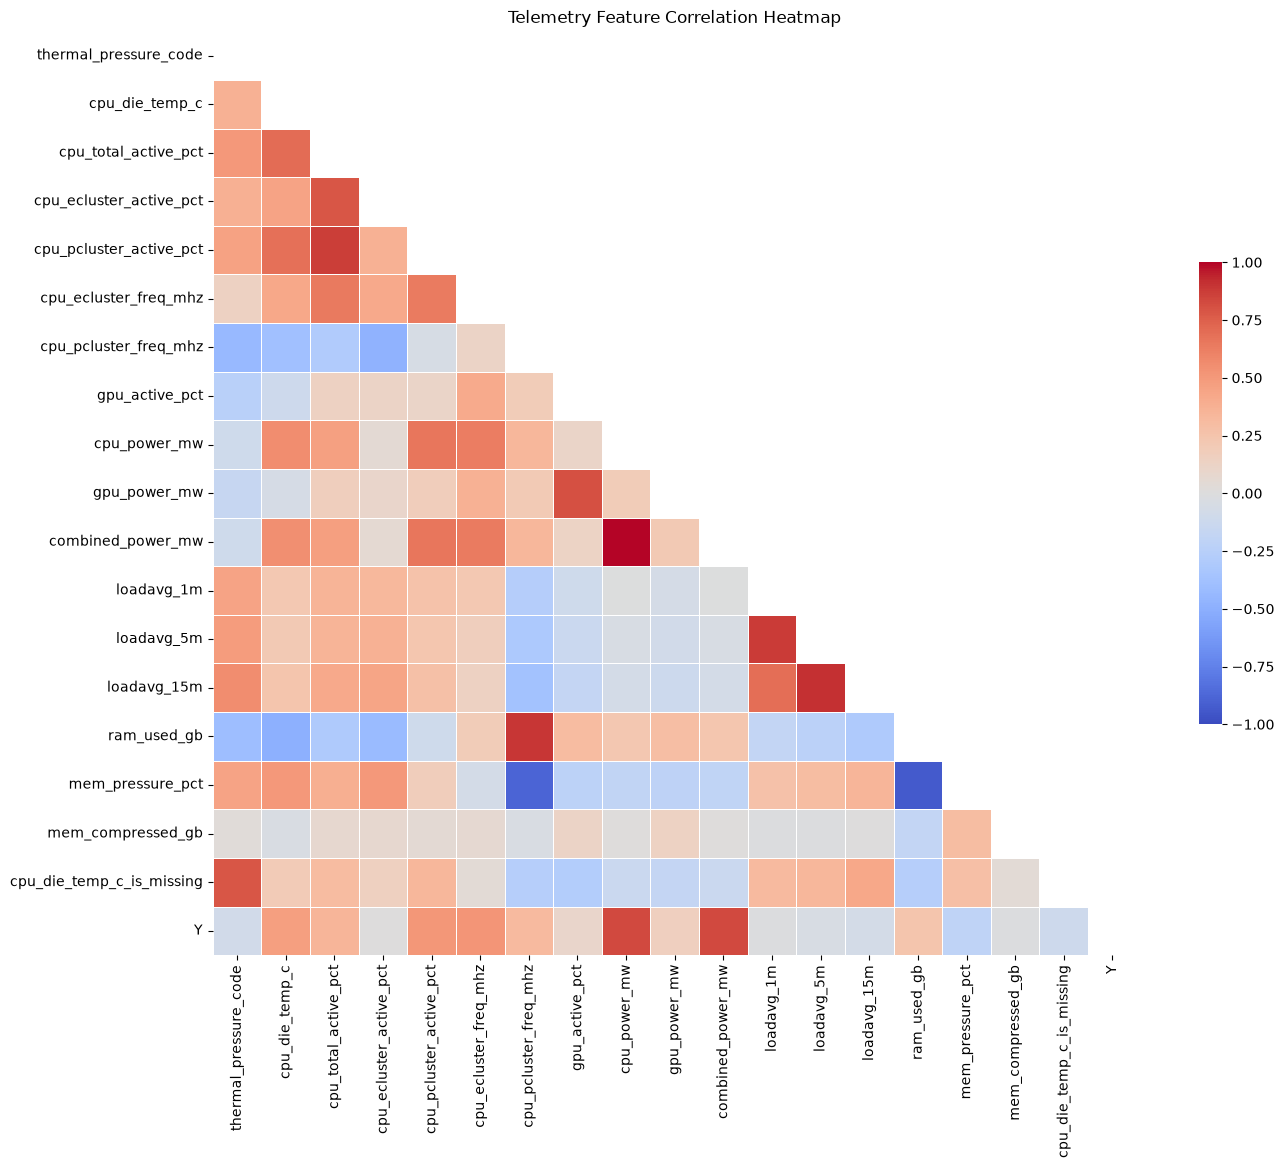


--- Multicollinearity Warnings (r > 0.85) ---
Feature 'cpu_pcluster_active_pct' is highly correlated with ['cpu_total_active_pct']. Consider dropping for linear models.
Feature 'combined_power_mw' is highly correlated with ['cpu_power_mw']. Consider dropping for linear models.
Feature 'loadavg_5m' is highly correlated with ['loadavg_1m']. Consider dropping for linear models.
Feature 'loadavg_15m' is highly correlated with ['loadavg_5m']. Consider dropping for linear models.
Feature 'ram_used_gb' is highly correlated with ['cpu_pcluster_freq_mhz']. Consider dropping for linear models.
Feature 'mem_pressure_pct' is highly correlated with ['cpu_pcluster_freq_mhz', 'ram_used_gb']. Consider dropping for linear models.

--- Top 10 Positively Correlated Features with Target ---
cpu_power_mw               0.832292
combined_power_mw          0.832058
cpu_ecluster_freq_mhz      0.520232
cpu_pcluster_active_pct    0.513756
cpu_total_active_pct       0.345989
cpu_pcluster_freq_mhz      0.318079
r

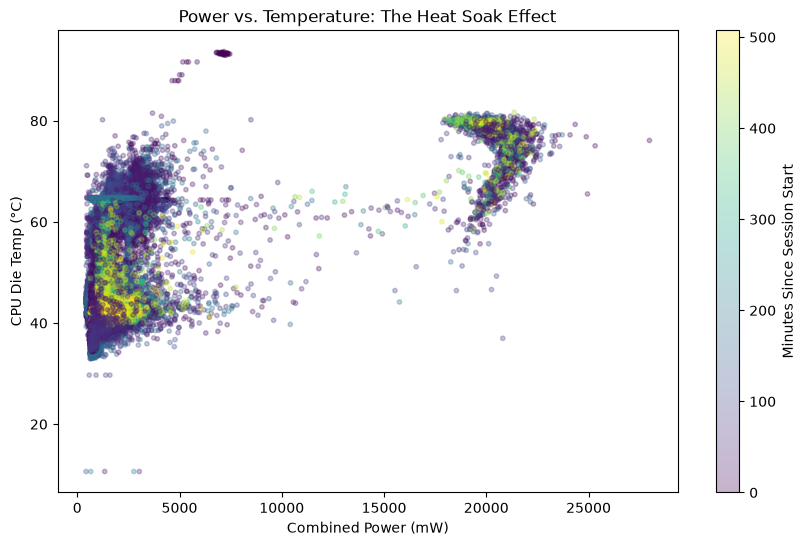

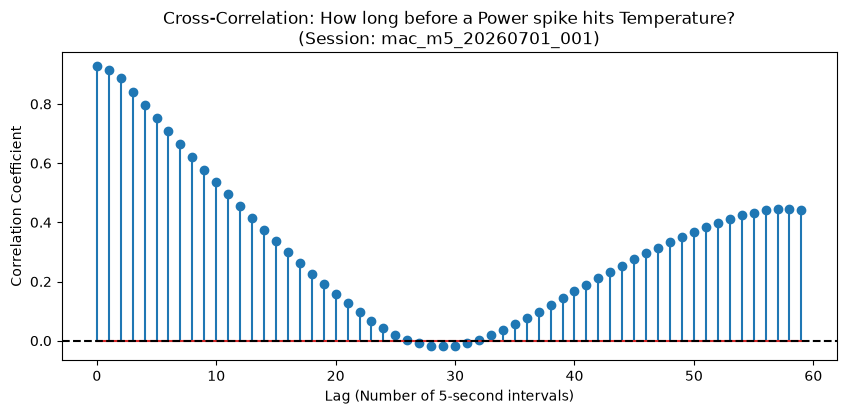


Maximum correlation occurs at a lag of 0 intervals (0 seconds).


In [7]:
plot_univariate_distributions(df_final, target_col="Y")
plot_correlation_heatmap(df_final)
test_heat_soak_assumption(df_final)
plot_power_temp_crosscorr_eda(df_final)

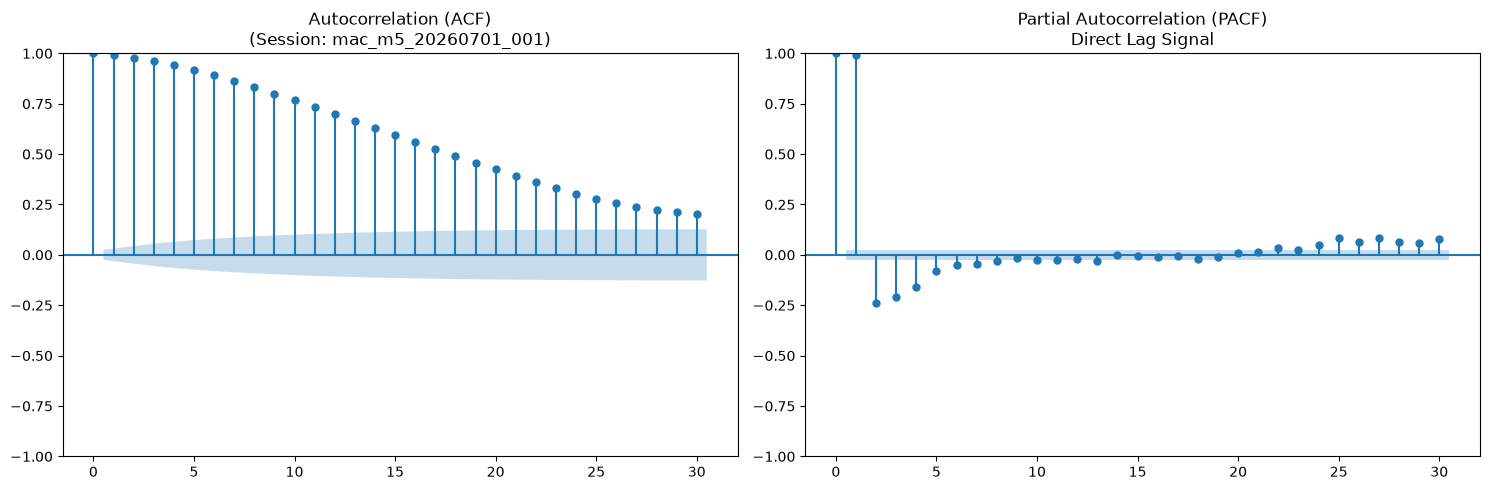


💡 INTERPRETATION:
Look at the PACF plot (right). The point where the stems fall inside the blue shaded area
is where historical data stops providing *new* direct information. Use this to set your max lag features.


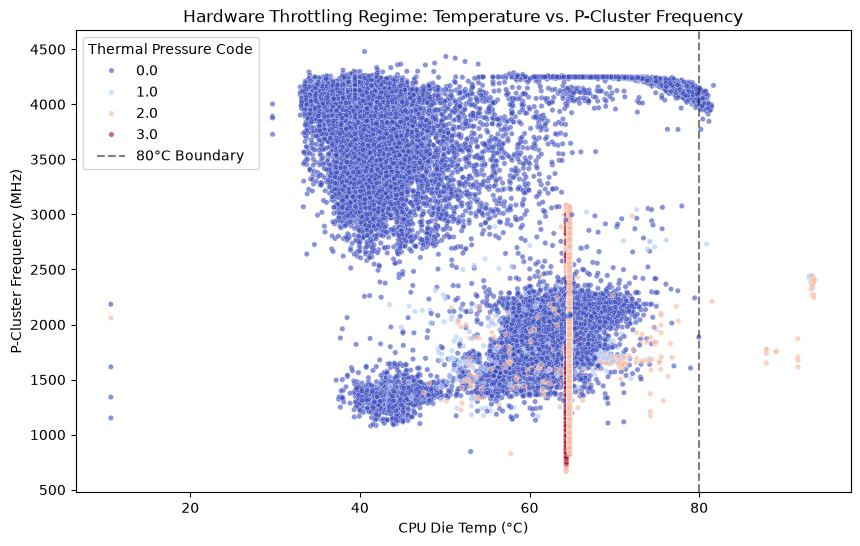

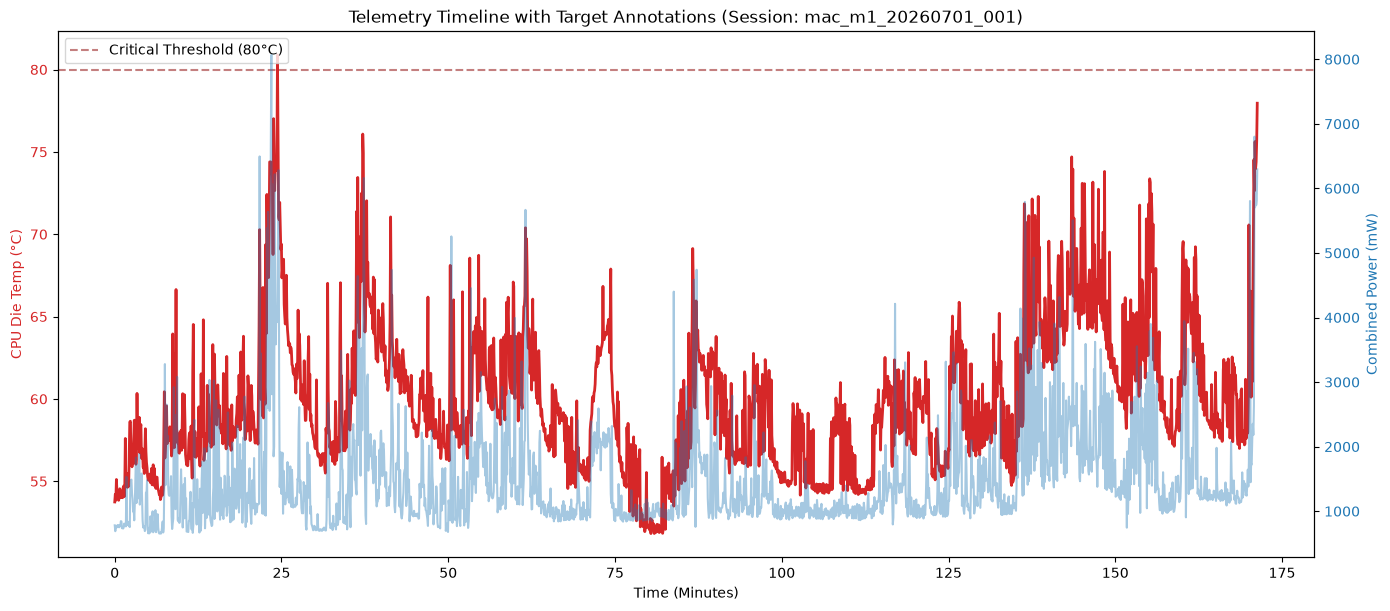


--- Baseline Target Signal (Mutual Information) ---
combined_power_mw              0.1947
cpu_power_mw                   0.1946
cpu_pcluster_active_pct        0.1724
cpu_ecluster_freq_mhz          0.1477
mem_compressed_gb              0.1355
cpu_total_active_pct           0.1138
cpu_pcluster_freq_mhz          0.1024
gpu_power_mw                   0.0794
loadavg_1m                     0.0598
loadavg_5m                     0.0469

💡 Note: Features with high MI scores are your strongest baseline predictors.


In [8]:
plot_autocorrelation(df_final, target_col="cpu_die_temp_c", lags=30)
plot_throttling_regime(df_final)
plot_annotated_timeline(df_final, session_idx=0)
calculate_baseline_target_importance(df_final, target_col="Y")

In [9]:
from data_features import engineer_features, drop_invalid_rows

df_features = engineer_features(df_final)
df_ml_ready = drop_invalid_rows(df_features)

2026-07-10 18:04:04,497 [INFO] Engineering features grouped by session_id.
2026-07-10 18:04:04,605 [INFO] Feature engineering complete.
2026-07-10 18:04:04,614 [INFO] Dropped 377 boundary rows with invalid feature history.


In [10]:
# drop cpu_die_temp_c because it is used to construct the target variable Y
#df_ml_ready = df_ml_ready.drop(columns=["cpu_die_temp_c"])

In [11]:
# compute the correlation highest with the target variable Y
TARGET_COL = "Y"
correlations = df_ml_ready.select_dtypes(include="number").corr()[TARGET_COL].abs().sort_values(ascending=False)

# set display options to all rows
pd.set_option('display.max_rows', None)
# display correlations as pd.Series
display(correlations)

Y                                         1.000000
pcluster_power_pressure                   0.832634
cpu_power_mw                              0.827800
combined_power_mw                         0.827574
cpu_power_mw_lag_1                        0.795278
combined_power_mw_lag_1                   0.795115
combined_power_mw_roll_mean_30s           0.774298
cpu_power_mw_roll_mean_30s                0.774205
cpu_power_mw_lag_2                        0.761885
combined_power_mw_lag_2                   0.761770
cpu_power_mw_roll_max_30s                 0.749555
combined_power_mw_roll_max_30s            0.749147
combined_power_mw_roll_min_30s            0.743043
cpu_power_mw_roll_min_30s                 0.742758
cpu_power_mw_lag_3                        0.727077
combined_power_mw_lag_3                   0.727016
combined_power_mw_roll_mean_1m            0.696988
cpu_power_mw_roll_mean_1m                 0.696790
cpu_power_mw_lag_4                        0.691938
combined_power_mw_lag_4        

In [12]:
df_ml_ready.shape

(23306, 142)

In [13]:
from data_prep import chronological_session_split_raw, separate_raw

train_df, val_df, test_df = chronological_session_split_raw(df_ml_ready)

X_train, y_train, meta_train = separate_raw(train_df)
X_val, y_val, meta_val = separate_raw(val_df)
X_test, y_test, meta_test = separate_raw(test_df)

rf, gb, rf_imp, gb_imp = fit_tree_importance(X_train, y_train, X_train.columns)

print("RF top 20")
display(rf_imp.head(20))

print("GB top 20")
display(gb_imp.head(20))

perm_imp, perm_std = get_permutation_importance(rf, X_val, y_val, X_val.columns, scoring="f1")
print("Permutation top 20 - Random Forest")
display(perm_imp.head(20))

print("Permutation top 20 - Gradient Boosting")
perm_imp_gb, perm_std_gb = get_permutation_importance(gb, X_val, y_val, X_val.columns, scoring="f1")
display(perm_imp_gb.head(20))

RF top 20


pcluster_power_pressure                 0.059688
combined_power_mw                       0.057536
cpu_power_mw                            0.048923
cpu_pcluster_active_pct_roll_max_30s    0.041949
combined_power_mw_roll_max_30s          0.040056
cpu_power_mw_roll_max_30s               0.039636
cpu_pcluster_active_pct                 0.031658
cpu_total_active_pct                    0.031628
cpu_power_mw_lag_1                      0.030339
combined_power_mw_roll_mean_30s         0.027029
cpu_die_temp_c                          0.025629
cpu_die_temp_c_diff_6                   0.025092
cpu_power_mw_lag_2                      0.022419
cpu_pcluster_active_pct_roll_max_1m     0.021874
cpu_power_mw_roll_mean_30s              0.020460
combined_power_mw_lag_1                 0.019192
cpu_die_temp_c_diff_1                   0.019001
cpu_power_mw_roll_max_1m                0.017839
cpu_pcluster_active_pct_lag_2           0.016662
combined_power_mw_roll_max_5m           0.015716
dtype: float64

GB top 20


pcluster_power_pressure           0.765086
cpu_die_temp_c_diff_6             0.097939
cpu_die_temp_c                    0.039993
combined_power_mw_roll_max_5m     0.006649
cpu_die_temp_c_lag_10             0.005896
cpu_die_temp_c_diff_1             0.005879
cpu_die_temp_c_roll_std_1m        0.005063
loadavg_5m                        0.004403
cpu_die_temp_c_roll_mean_5m       0.003317
combined_power_mw_roll_mean_5m    0.003085
cpu_die_temp_c_roll_mean_15m      0.002806
cpu_die_temp_c_roll_range_5m      0.002736
cpu_die_temp_c_roll_min_5m        0.002635
cpu_die_temp_c_roll_min_1m        0.002584
loadavg_1m                        0.002444
cpu_power_mw_roll_max_5m          0.002305
combined_power_mw_roll_std_5m     0.002191
cpu_die_temp_c_lag_1              0.002001
cpu_die_temp_c_roll_range_1m      0.001908
cpu_power_mw_roll_mean_5m         0.001814
dtype: float64

Permutation top 20 - Random Forest


combined_power_mw                       0.139926
cpu_die_temp_c_roll_range_5m            0.112672
cpu_die_temp_c                          0.106546
cpu_die_temp_c_roll_std_5m              0.092122
cpu_power_mw_lag_1                      0.091794
cpu_die_temp_c_roll_mean_1m             0.091794
cpu_power_mw_roll_max_1m                0.091794
cpu_pcluster_active_pct                 0.087330
cpu_power_mw_roll_mean_30s              0.085875
combined_power_mw_roll_max_5m           0.079957
cpu_power_mw_roll_max_5m                0.079957
cpu_pcluster_active_pct_roll_max_1m     0.071862
cpu_power_mw_roll_mean_1m               0.070584
combined_power_mw_lag_1                 0.064666
pcluster_power_pressure                 0.061041
cpu_pcluster_active_pct_roll_max_30s    0.048522
cpu_die_temp_c_roll_mean_30s            0.047307
cpu_die_temp_c_roll_max_30s             0.047279
combined_power_mw_lag_2                 0.022129
cpu_power_mw_lag_2                      0.022129
dtype: float64

Permutation top 20 - Gradient Boosting


combined_power_mw_roll_max_1m            0.024528
cpu_die_temp_c                           0.020636
cpu_die_temp_c_diff_1                    0.019187
cpu_die_temp_c_roll_range_30s            0.011520
cpu_die_temp_c_roll_std_5m               0.010515
cpu_die_temp_c_roll_range_1m             0.003665
combined_power_mw_roll_min_1m            0.001841
cpu_pcluster_active_pct_roll_max_30s     0.000798
cpu_pcluster_active_pct_roll_range_1m    0.000711
cpu_pcluster_freq_mhz_roll_range_5m      0.000300
cpu_pcluster_freq_mhz_roll_std_5m        0.000236
cpu_die_temp_c_roll_min_30s              0.000213
cpu_die_temp_c_roll_max_30s              0.000200
loadavg_15m                              0.000200
cpu_pcluster_freq_mhz_roll_min_5m        0.000175
cpu_pcluster_active_pct_roll_mean_5m     0.000175
cpu_pcluster_freq_mhz_accel              0.000150
cpu_pcluster_freq_mhz_roll_mean_5m       0.000063
cpu_pcluster_freq_mhz_roll_std_30s       0.000038
cpu_die_temp_c_roll_max_5m               0.000012


In [14]:
from data_features import aggregate_family_importance
print("\n--- RF permutation importance by feature family ---")
display(aggregate_family_importance(perm_imp))

# Step 5 — identify features safe to drop
# Negative permutation importance means the feature HURTS the model
safe_to_drop = perm_imp[perm_imp <= 0].index.tolist()
low_contribution = perm_imp[(perm_imp > 0) & (perm_imp < 0.002)].index.tolist()

print(f"\nSafe to drop (perm imp <= 0): {len(safe_to_drop)}")
print(safe_to_drop)
print(f"\nLow contribution (perm imp < 0.002): {len(low_contribution)}")


--- RF permutation importance by feature family ---


family
rolling        1.041434
raw_core       0.342654
lag            0.248428
interaction    0.061041
diff           0.021129
other          0.017703
accel          0.007745
Name: importance, dtype: float64


Safe to drop (perm imp <= 0): 90
['cpu_total_active_pct', 'cpu_ecluster_active_pct', 'gpu_active_pct', 'cpu_pcluster_freq_mhz', 'cpu_power_mw_lag_3', 'cpu_power_mw_lag_5', 'cpu_die_temp_c_lag_2', 'cpu_die_temp_c_lag_4', 'cpu_power_mw_lag_4', 'cpu_die_temp_c_is_missing', 'cpu_pcluster_active_pct_lag_5', 'cpu_pcluster_active_pct_lag_4', 'cpu_pcluster_active_pct_lag_3', 'combined_power_mw_lag_10', 'combined_power_mw_lag_4', 'combined_power_mw_lag_5', 'cpu_power_mw_lag_10', 'combined_power_mw_lag_3', 'cpu_die_temp_c_lag_10', 'cpu_die_temp_c_lag_5', 'ram_used_gb', 'mem_pressure_pct', 'mem_compressed_gb', 'loadavg_15m', 'loadavg_1m', 'loadavg_5m', 'combined_power_mw_roll_range_1m', 'combined_power_mw_roll_min_1m', 'combined_power_mw_roll_max_1m', 'combined_power_mw_roll_std_1m', 'combined_power_mw_roll_range_30s', 'combined_power_mw_roll_min_30s', 'combined_power_mw_roll_max_30s', 'combined_power_mw_roll_std_30s', 'cpu_die_temp_c_roll_mean_5m', 'cpu_die_temp_c_roll_min_5m', 'cpu_die_temp_c_

In [15]:
KEEP_COLS = [
    "pcluster_power_pressure",
    "cpu_power_mw",
    "combined_power_mw",
    "combined_power_mw_is_high",
    "cpu_pcluster_active_pct",
    "cpu_die_temp_c_lag_1",
    "cpu_total_active_pct",
    "combined_power_mw_roll_max_30s",
    "cpu_die_temp_c_roll_max_30s",
    "cpu_power_mw_is_high",
    "combined_power_mw_lag_1",
    "cpu_pcluster_active_pct_lag_1",
    "cpu_die_temp_c_diff_6",
    "cpu_power_mw_lag_1",
    "cpu_die_temp_c_diff_1",
    "combined_power_mw_roll_mean_30s",
    "thermal_distress_proxy",
    "cpu_power_mw_roll_max_30s",
    "cpu_pcluster_active_pct_roll_max_30s",
    "cpu_ecluster_freq_mhz",
    "cpu_die_temp_c_roll_mean_30s",
    "loadavg_5m",
    "cpu_pcluster_freq_mhz",
    "ram_used_gb",
]

keep_all = ["session_id", "timestamp_utc", "Y"] + KEEP_COLS
df_final_model = df_ml_ready[[c for c in keep_all if c in df_ml_ready.columns]].copy()
splits = build_ml_splits(df_final_model)

X_train, y_train, meta_train = splits["train"]
X_val, y_val, meta_val = splits["val"]
X_test, y_test, meta_test = splits["test"]
bundle = splits["bundle"]

2026-07-10 18:05:15,675 [INFO] Chronological session split — train 70% / val 15% / test 15%.
2026-07-10 18:05:15,682 [INFO] Sessions assigned — train: 9, val: 2, test: 2.
2026-07-10 18:05:15,694 [INFO] Column routing — passthrough: 0, multimodal_base: 7, multimodal_children: 10, diff/accel (YJ): 2, box-cox: 3, yj-fallback: 0
2026-07-10 18:05:15,776 [INFO] Box-Cox fitted on 3 columns.
2026-07-10 18:05:15,799 [INFO] Yeo-Johnson fitted on 2 columns (2 diff/accel + 0 other fallback).
2026-07-10 18:05:15,801 [INFO] Preprocessing bundle saved to artifacts/preprocessors.joblib.
2026-07-10 18:05:15,801 [INFO] Transforming X_train...
2026-07-10 18:05:15,809 [INFO] Transforming X_val...
2026-07-10 18:05:15,814 [INFO] Transforming X_test...


In [16]:
X_train.shape

(15852, 29)

In [17]:
X_train.head()

,pcluster_power_pressure,cpu_power_mw,combined_power_mw,cpu_pcluster_active_pct,cpu_die_temp_c_lag_1,cpu_total_active_pct,combined_power_mw_roll_max_30s,cpu_die_temp_c_roll_max_30s,combined_power_mw_lag_1,cpu_pcluster_active_pct_lag_1,...,loadavg_5m,cpu_pcluster_freq_mhz,ram_used_gb,cpu_power_mw_is_high,combined_power_mw_is_high,cpu_pcluster_active_pct_is_high,cpu_total_active_pct_is_high,loadavg_5m_is_high,cpu_pcluster_freq_mhz_is_high,ram_used_gb_is_high
0,0.398279,0.286662,0.215026,0.502853,1.096790,0.604033,-0.218129,0.893379,0.186345,0.473092,...,2.452887,-1.391281,-2.102071,0,0,0,0,1,0,0
1,0.332928,0.227647,0.225638,0.433157,0.995928,0.618160,-0.212436,0.893379,0.214651,0.502583,...,2.393060,-1.533750,-2.098480,0,0,0,0,1,0,0
2,0.253721,0.053963,0.038978,0.484474,0.959496,0.601294,-0.212436,0.893379,0.225256,0.432914,...,2.374713,-1.704592,-2.137478,0,0,0,0,1,0,0
3,0.105295,-0.060952,-0.049879,0.361430,0.900488,0.473470,-0.212436,0.893379,0.038721,0.484211,...,2.343205,-1.518978,-2.086645,0,0,0,0,1,0,0
4,-0.279298,-0.279307,-0.223184,0.095526,0.948683,0.287983,-0.212436,0.893379,-0.050076,0.361215,...,2.434141,-1.617014,-2.074918,0,0,0,0,1,0,0


In the following cells we are going to train different models with different class balancing techniques (no balancing, class weights, random oversampling, SMOTE and threshold moving after probability prediction)

In [18]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

rand_state=42


### Logistic regression

In [19]:
# --- A. Baseline ---
lr_baseline = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_baseline.fit(X_train, y_train)

# --- B. Class Weights ---
lr_weighted = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=rand_state)
lr_weighted.fit(X_train, y_train)


# --- C. Random oversampling ---
ros = RandomOverSampler(random_state=rand_state)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
lr_rand_oversamp = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_rand_oversamp.fit(X_train_ros, y_train_ros)


# --- D. SMOTE ---
smote = SMOTE(random_state=rand_state)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
lr_smote = LogisticRegression(max_iter=1000, random_state=rand_state)
lr_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving ---
val_probs = lr_baseline.predict_proba(X_val)[:, 1]
best_thresh = 0.5
best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > best_f1:
        best_f1, best_thresh = score, t




### Random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
# --- A. Baseline ---
rf_baseline = RandomForestClassifier(random_state=rand_state)
rf_baseline.fit(X_train, y_train)

# --- B. Class Weights ---
rf_weighted = RandomForestClassifier(class_weight="balanced", random_state=rand_state)
rf_weighted.fit(X_train, y_train)

# --- C. Random oversampling ---
ros = RandomOverSampler(random_state=rand_state)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
rf_rand_oversamp = RandomForestClassifier(random_state=rand_state)
rf_rand_oversamp.fit(X_train_ros, y_train_ros)

# --- D. SMOTE ---
smote = SMOTE(random_state=rand_state)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
rf_smote = RandomForestClassifier(random_state=rand_state)
rf_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving (Optimized on RF Baseline) ---
rf_val_probs = rf_baseline.predict_proba(X_val)[:, 1]
rf_best_thresh = 0.5
rf_best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (rf_val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > rf_best_f1:
        rf_best_f1, rf_best_thresh = score, t

### Gradient boosting

In [21]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# --- A. Baseline ---
gb_baseline = GradientBoostingClassifier(random_state=rand_state)
gb_baseline.fit(X_train, y_train)

# --- B. Class Weights (via Sample Weights) ---
gb_sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
gb_weighted = GradientBoostingClassifier(random_state=rand_state)
gb_weighted.fit(X_train, y_train, sample_weight=gb_sample_weights)

# --- C. Random Oversampling ---
X_train_ros, y_train_ros = RandomOverSampler(random_state=rand_state).fit_resample(X_train, y_train)
gb_rand_oversamp = GradientBoostingClassifier(random_state=rand_state)
gb_rand_oversamp.fit(X_train_ros, y_train_ros)

# --- D. SMOTE ---
X_train_sm, y_train_sm = SMOTE(random_state=rand_state).fit_resample(X_train, y_train)
gb_smote = GradientBoostingClassifier(random_state=rand_state)
gb_smote.fit(X_train_sm, y_train_sm)

# --- E. Threshold Moving ---
gb_val_probs = gb_baseline.predict_proba(X_val)[:, 1]
gb_best_thresh = 0.5
gb_best_f1 = 0
for t in np.linspace(0, 1, 100):
    preds = (gb_val_probs >= t).astype(int)
    score = f1_score(y_val, preds)
    if score > gb_best_f1:
        gb_best_f1, gb_best_thresh = score, t

### Newral network

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- A. Baseline ---
train_loader_base = make_loader(X_train, y_train, shuffle=True)
mlp_baseline = train_pytorch_model(train_loader_base, input_dim=X_train.shape[1], device=device)


# --- B. Class Weights ---
# Extract values safely to support pandas Series operations
y_train_arr = y_train.values if hasattr(y_train, "values") else y_train
neg_count = np.sum(y_train_arr == 0)
pos_count = np.sum(y_train_arr == 1)
pos_weight_value = neg_count / pos_count

train_loader_weighted = make_loader(X_train, y_train, shuffle=True)
mlp_weighted = train_pytorch_model(
    train_loader_weighted, 
    input_dim=X_train.shape[1], 
    device=device,              # Added device parameter
    pos_weight=pos_weight_value
)


# --- C. Random Oversampling ---
ros = RandomOverSampler(random_state=rand_state)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

train_loader_ros = make_loader(X_train_ros, y_train_ros, shuffle=True)
mlp_rand_oversamp = train_pytorch_model(train_loader_ros, input_dim=X_train.shape[1], device=device)


# --- D. SMOTE ---
smote = SMOTE(random_state=rand_state)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

train_loader_sm = make_loader(X_train_sm, y_train_sm, shuffle=True)
mlp_smote = train_pytorch_model(train_loader_sm, input_dim=X_train.shape[1], device=device)


# --- E. Threshold Moving ---
# Remember to pass device here as well so the tensors load properly
mlp_val_probs = get_probabilities(mlp_baseline, X_val, device=device)

mlp_best_thresh = 0.5
mlp_best_f1 = 0

for t in np.linspace(0, 1, 100):
    preds = (mlp_val_probs >= t).astype(int)
    score = f1_score(y_val, preds, zero_division=0)
    if score > mlp_best_f1:
        mlp_best_f1 = score
        mlp_best_thresh = t

##### Class balancing technique performance overview

In [26]:

#Structure to hold all trained models, their variations, and their type
all_models = {
    "Logistic Regression": {
        "Baseline": lr_baseline,
        "Class Weights": lr_weighted,
        "Random Oversampling": lr_rand_oversamp,
        "SMOTE": lr_smote,
        "type": "sklearn",
    },
    "Random Forest": {
        "Baseline": rf_baseline,
        "Class Weights": rf_weighted,
        "Random Oversampling": rf_rand_oversamp,
        "SMOTE": rf_smote,
        "type": "sklearn",
    },
    "Gradient Boosting": {
        "Baseline": gb_baseline,
        "Class Weights": gb_weighted,
        "Random Oversampling": gb_rand_oversamp,
        "SMOTE": gb_smote,
        "type": "sklearn",
    },
    "Neural Network": {
        "Baseline": mlp_baseline,
        "Class Weights": mlp_weighted,
        "Random Oversampling": mlp_rand_oversamp,
        "SMOTE": mlp_smote,
        "type": "pytorch",
    },
}

# Dictionary to collect all results for the final master table
final_results = {}

#Iterate through each model type
for model_name, techniques in all_models.items():
    is_pytorch = techniques["type"] == "pytorch"
    standard_strats = ["Baseline", "Class Weights", "Random Oversampling", "SMOTE"]

    # ----------------------------------------------------------------
    # Evaluate Standard Techniques (Using default 0.5 Threshold)
    # ----------------------------------------------------------------
    for strat in standard_strats:
        model = techniques[strat]

        if is_pytorch:
            # Extract raw continuous probabilities via sigmoid
            val_probs = get_probabilities(model, X_val, device=device)
            # Apply standard default 0.5 classification threshold
            val_preds = (val_probs >= 0.5).astype(int)
        else:
            val_preds = model.predict(X_val)

        # Validation evaluation
        val_prec = precision_score(y_val, val_preds, zero_division=0)
        val_rec = recall_score(y_val, val_preds, zero_division=0)
        val_f1 = f1_score(y_val, val_preds, zero_division=0)

        # Store metrics (Validation only)
        final_results[f"{model_name} - {strat}"] = {
            "Val Prec": val_prec,
            "Val Rec": val_rec,
            "Val F1": val_f1
        }

    # ----------------------------------------------------------------
    # Optimize & Evaluate Threshold Moving (on the Baseline Model)
    # ----------------------------------------------------------------
    baseline_model = techniques["Baseline"]

    # Get raw probabilities cleanly regardless of platform
    if is_pytorch:
        val_probs = get_probabilities(baseline_model, X_val, device=device)
    else:
        val_probs = baseline_model.predict_proba(X_val)[:, 1]

    # Find best threshold on Validation Set
    best_thresh = 0.5
    best_val_f1 = 0

    for t in np.linspace(0, 1, 100):
        preds = (val_probs >= t).astype(int)
        score = f1_score(y_val, preds, zero_division=0)
        if score > best_val_f1:
            best_val_f1 = score
            best_thresh = t

    # Calculate final validation metrics at the optimized threshold
    val_preds_t = (val_probs >= best_thresh).astype(int)
    val_prec_t = precision_score(y_val, val_preds_t, zero_division=0)
    val_rec_t = recall_score(y_val, val_preds_t, zero_division=0)

    # Store metrics (Validation only)
    final_results[f"{model_name} - Thresh Moving (t={best_thresh:.2f})"] = {
        "Val Prec": val_prec_t,
        "Val Rec": val_rec_t,
        "Val F1": best_val_f1
    }

# ----------------------------------------------------------------
#Display Global Validation Comparison Matrix
# ----------------------------------------------------------------
df_comparison = pd.DataFrame(final_results).T

print(
    "\n=========================================================================")
print(
    "===                     ALL TECHNIQUES: VALIDATION METRICS             ===")
print(
    "=========================================================================")
print(df_comparison.round(4).to_string())




===                     ALL TECHNIQUES: VALIDATION METRICS             ===
                                              Val Prec  Val Rec  Val F1
Logistic Regression - Baseline                  0.5667   0.2152  0.3119
Logistic Regression - Class Weights             0.1784   0.4177  0.2500
Logistic Regression - Random Oversampling       0.2215   0.4177  0.2895
Logistic Regression - SMOTE                     0.1556   0.4430  0.2303
Logistic Regression - Thresh Moving (t=0.46)    0.6176   0.2658  0.3717
Random Forest - Baseline                        0.8571   0.3038  0.4486
Random Forest - Class Weights                   0.3171   0.1646  0.2167
Random Forest - Random Oversampling             0.4000   0.0759  0.1277
Random Forest - SMOTE                           0.1864   0.1392  0.1594
Random Forest - Thresh Moving (t=0.40)          0.6981   0.4684  0.5606
Gradient Boosting - Baseline                    0.5278   0.2405  0.3304
Gradient Boosting - Class Weights               0.2500   0.2

From the test we can see that the basiline (no class imbalance handling) had a better performance upon other techniques, so we move on using baseline data to hyperparameter tuning

In [ ]:

best_models_archive = {}
tuning_summary = []
N_ITER = 5  # Number of random parameter combinations to try per model architecture

# ----------------------------------------------------------------
# Define Search Spaces for All 4 Architectures
# ----------------------------------------------------------------
param_spaces = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1.0, 10.0]
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    },
    "Neural Network": {
        "hidden_dim": [32, 64, 128],
        "lr": [0.001, 0.005, 0.01],
        "epochs": [15, 25],
    },
}

# ----------------------------------------------------------------
# Execution Pipeline Loop
# ----------------------------------------------------------------
for algo_name, space in param_spaces.items():
    print(f"\nTuning {algo_name}...")

    global_best_f1 = -1
    global_best_accuracy = -1
    global_best_params = None
    global_best_model_obj = None

    # Generate random combinations of hyperparameters
    keys, values = zip(*space.items())
    experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]
    sampled_experiments = random.sample(
        experiments, min(N_ITER, len(experiments))
    )

    for config in sampled_experiments:
        # Initialize and Train Model based on platform type
        if algo_name == "Neural Network":
            train_loader = make_loader(
                X_train, y_train, batch_size=64, shuffle=True
            )
            model = PyTorchMLP(
                input_dim=X_train.shape[1], hidden_dim=config["hidden_dim"]
            ).to(device)
            optimizer = optim.Adam(model.parameters(), lr=config["lr"])
            criterion = nn.BCEWithLogitsLoss()

            model.train()
            for epoch in range(config["epochs"]):
                for batch_X, batch_y in train_loader:
                    optimizer.zero_grad()
                    loss = criterion(
                        model(batch_X.to(device)), batch_y.to(device)
                    )
                    loss.backward()
                    optimizer.step()

            val_probs = get_probabilities(model, X_val, device=device)
            # Evaluate using a rigid 0.50 cutoff
            preds = (val_probs >= 0.50).astype(int)
        else:
            if algo_name == "Logistic Regression":
                model = LogisticRegression(
                    **config, max_iter=1000, random_state=rand_state
                )
            elif algo_name == "Random Forest":
                model = RandomForestClassifier(**config, random_state=rand_state)
            elif algo_name == "Gradient Boosting":
                model = GradientBoostingClassifier(
                    **config, random_state=rand_state
                )

            model.fit(X_train, y_train)
            # Evaluate using standard built-in 0.50 cutoff predict step
            preds = model.predict(X_val)

        # Calculate metrics for the current parameter variation
        score_f1 = f1_score(y_val, preds, zero_division=0)
        score_acc = accuracy_score(y_val, preds)

        # Track global winner based on F1-Score performance
        if score_f1 > global_best_f1:
            global_best_f1 = score_f1
            global_best_accuracy = score_acc
            global_best_params = config
            global_best_model_obj = model

    # Archive the best settings found
    best_models_archive[algo_name] = {
        "model_object": global_best_model_obj,
        "type": "pytorch" if algo_name == "Neural Network" else "sklearn",
    }

    tuning_summary.append(
        {
            "Algorithm": algo_name,
            "Best Val F1": global_best_f1,
            "Best Val Accuracy": global_best_accuracy,
            "Best Parameters": global_best_params,
        }
    )

# Print out Leaderboard Results
df_leaderboard = pd.DataFrame(tuning_summary)
print(
    "\n========================================================================="
)
print(
    "===             HYPERPARAMETER TUNING LEADERBOARD           ==="
)
print(
    "========================================================================="
)
print(df_leaderboard.round(4).to_string(index=False))


Tuning Logistic Regression...

Tuning Random Forest...

Tuning Gradient Boosting...

Tuning Neural Network...

===             HYPERPARAMETER TUNING LEADERBOARD (t=0.50)           ===
          Algorithm  Best Val F1  Best Val Accuracy                                                 Best Parameters
Logistic Regression       0.3423             0.9803                                                     {'C': 10.0}
      Random Forest       0.5739             0.9868 {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 10}
  Gradient Boosting       0.4310             0.9822    {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 5}
     Neural Network       0.2281             0.9763                   {'hidden_dim': 32, 'lr': 0.001, 'epochs': 25}


Amongst the models, random forest performed best. We proceed to make the final prodiction using it

In [ ]:
global_winner_name = df_leaderboard.sort_values(
    by="Best Val F1", ascending=False
).iloc[0]["Algorithm"]

winner_meta = best_models_archive[global_winner_name]
best_model = winner_meta["model_object"]

#Get predictions and raw positive-class probabilities
if winner_meta["type"] == "pytorch":
    test_probabilities = get_probabilities(best_model, X_test, device=device)
    final_test_predictions = (test_probabilities >= 0.50).astype(int)
else:
    test_probabilities = best_model.predict_proba(X_test)[:, 1]
    final_test_predictions = best_model.predict(X_test)

#Calculate ROC-AUC and PR-AUC metrics
# Compute ROC-AUC directly from probabilities
roc_auc = roc_auc_score(y_test, test_probabilities)

# Compute PR-AUC by calculating the precision/recall curves across thresholds
precisions, recalls, _ = precision_recall_curve(y_test, test_probabilities)
pr_auc = auc(recalls, precisions)

#Final detailed metrics report
print(f"\n=========================================================")
print(f"=== FINAL TEST EVALUATION: {global_winner_name} ===")
print(f"=========================================================")
print(classification_report(y_test, final_test_predictions, zero_division=0))

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score:  {pr_auc:.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, final_test_predictions))


=== FINAL TEST EVALUATION: Random Forest ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3683
           1       0.43      0.05      0.09        60

    accuracy                           0.98      3743
   macro avg       0.71      0.52      0.54      3743
weighted avg       0.98      0.98      0.98      3743

ROC-AUC Score: 0.5154
PR-AUC Score:  0.0424

=== Confusion Matrix ===
[[3679    4]
 [  57    3]]
